## Fase 2: Entendimiento de los datos

✏️ Carga los módulos necesarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

Matplotlib is building the font cache; this may take a moment.


✏️ Carga los datos.

In [54]:
data = pd.read_csv("../data/raw/Sacramento_Data.csv")
data.head()

,city,zip,beds,baths,sqft,type,price,latitude,longitude
0,SACRAMENTO,z95838,2,1.0,836,Residential,59222,38.631913,-121.434879
1,SACRAMENTO,z95823,3,1.0,1167,Residential,68212,38.478902,-121.431028
2,SACRAMENTO,z95815,2,1.0,796,Residential,68880,38.618305,-121.443839
3,SACRAMENTO,z95815,2,1.0,852,Residential,69307,38.616835,-121.439146
4,SACRAMENTO,z95824,2,1.0,797,Residential,81900,38.519470,-121.435768


✏️ Revisa la estructura del conjunto de datos.

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 932 entries, 0 to 931
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       932 non-null    object 
 1   zip        932 non-null    object 
 2   beds       932 non-null    int64  
 3   baths      932 non-null    float64
 4   sqft       932 non-null    int64  
 5   type       932 non-null    object 
 6   price      932 non-null    object 
 7   latitude   932 non-null    float64
 8   longitude  932 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 65.7+ KB


✏️ Si lo necesitas, realiza cualquier data type casting necesario.

In [19]:
data['price'] = pd.to_numeric(data['price'], errors='coerce')

✏️ Crea una tabla de frecuencia sobre la variable `type` para revisar incosistencias en las categorías.

In [17]:
data['type'].value_counts()

type
Residential     866
Condo            53
Multi_Family     13
Name: count, dtype: int64

✏️ Calcula estadísticas básicas.

In [18]:
data.describe()

,beds,baths,sqft,price,latitude,longitude
count,932.000000,932.000000,932.000000,931.000000,932.000000,932.000000
mean,3.275751,2.053112,1680.318670,246792.262084,38.592980,-121.360288
std,0.887998,0.722599,726.266383,131136.606857,0.134159,0.140178
min,1.000000,1.000000,484.000000,30000.000000,38.241514,-121.551704
25%,3.000000,2.000000,1166.750000,156000.000000,38.478436,-121.449257
50%,3.000000,2.000000,1470.000000,220000.000000,38.619343,-121.382474
75%,4.000000,2.000000,1953.500000,305000.000000,38.686063,-121.308444
max,8.000000,5.000000,4878.000000,884790.000000,39.020808,-120.597599


✏️ Separa el conjunto de datos en training y test set.

In [20]:
sklearn_train, sklearn_test = train_test_split(data, test_size = 0.3, random_state = 42)
sklearn_train.head()

,city,zip,beds,baths,sqft,type,price,latitude,longitude
133,SACRAMENTO,z95831,3,3.0,1638,Residential,370000.0,38.477200,-121.521500
507,GALT,z95632,4,2.0,1606,Residential,353767.0,38.253500,-121.318120
843,SACRAMENTO,z95824,3,2.0,1127,Residential,130000.0,38.520490,-121.411383
599,CITRUS_HEIGHTS,z95610,3,2.0,1410,Residential,160000.0,38.689239,-121.267737
497,ELK_GROVE,z95758,5,3.0,3468,Residential,320000.0,38.439565,-121.436606


✏️ Grafica la variable `price` para evaluar su distribución.

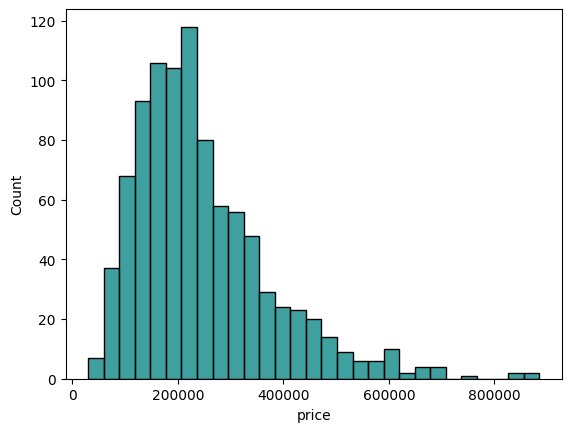

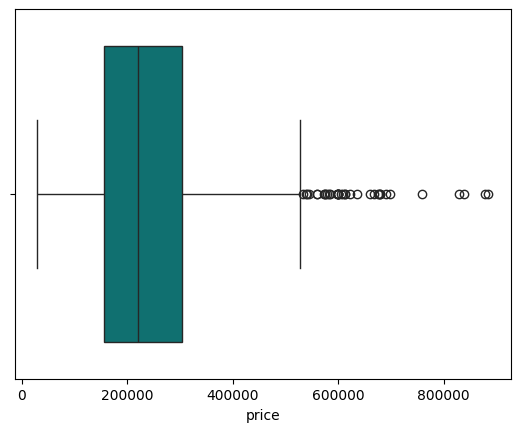

In [22]:
sns.histplot(data, x = 'price', color = 'teal')
plt.show()

sns.boxplot(data, x = 'price', color = 'teal')
plt.show()

✏️ Crea puntos de corte de la variable price basándote en los cuantiles 0.2, 0.4, 0.6 y 0.8.

In [23]:
price_cuts = data['price'].quantile([0.2, 0.4, 0.6, 0.8])
price_cuts

0.2    140800.0
0.4    194818.0
0.6    245000.0
0.8    334000.0
Name: price, dtype: float64

✏️ Crea una variable auxiliar llamada price_cat que discretice el precio de la vivienda según los puntos de corte que definiste anteriormente.

In [24]:
data["price_cat"] = pd.cut(data["price"], 
                           bins = [-np.inf, *price_cuts, np.inf], 
                           labels = [1, 2, 3, 4, 5])

✏️ Asegúrate de que esta variable incluya la proporción esperada de observaciones en cada categoría.

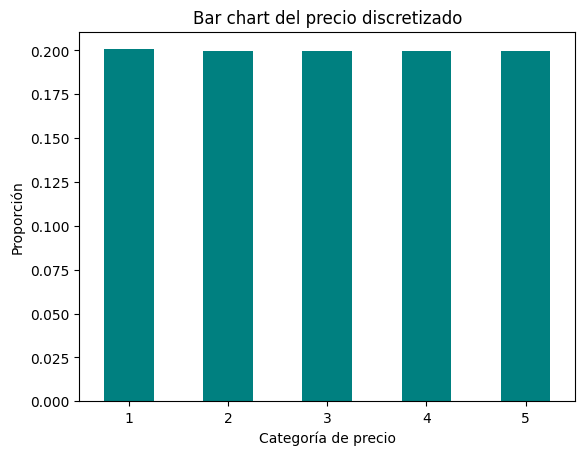

In [25]:
(data["price_cat"].value_counts() / len(data)).sort_index().plot.bar(rot = 0, color = "teal")

plt.xlabel("Categoría de precio")
plt.ylabel("Proporción")
plt.title("Bar chart del precio discretizado")
plt.show()

✏️ Divide el conjunto de datos original en training y test set estratificando por la variable `price_cat`.

In [27]:
nulos_en_cat = data["price_cat"].isnull().sum()
data = data.dropna(subset=["price_cat"])

In [28]:
strat_train, strat_test = train_test_split(data, 
                                           test_size = 0.3, 
                                           stratify = data["price_cat"], 
                                           random_state = 42)

✏️ Asegúrate de que la distribución del precio sea similar en estos dos nuevos conjuntos de datos.

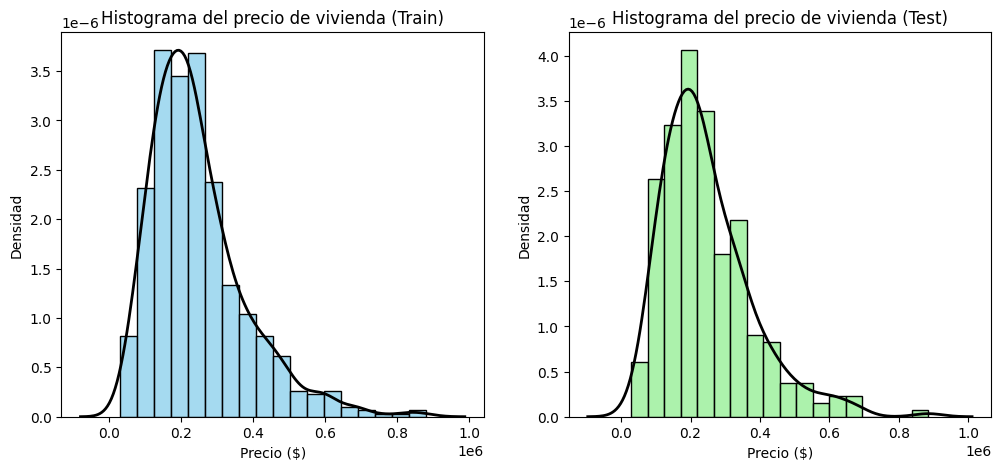

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

## Histograma y kernel plot en el training set
sns.histplot(strat_train, x = "price", ax = ax1, bins = 18, color = "skyblue", stat = "density")
sns.kdeplot(strat_train["price"], ax = ax1, color = "black", linewidth = 2)
ax1.set_title("Histograma del precio de vivienda (Train)")
ax1.set_xlabel("Precio ($)")
ax1.set_ylabel("Densidad")

## Histograma y kernel plot en el test set
sns.histplot(strat_test, x = "price", ax = ax2, bins = 18, color = "lightgreen", stat = "density")
sns.kdeplot(strat_test["price"], ax = ax2, color = "black", linewidth = 2)
ax2.set_title("Histograma del precio de vivienda (Test)")
ax2.set_xlabel("Precio ($)")
ax2.set_ylabel("Densidad")

plt.show()

✏️ Elimina la variable price_cat del training y test set.

In [30]:
for set_ in (strat_train, strat_test):
    set_.drop(columns = "price_cat", inplace = True)

✏️ Crea una copia del training set.

In [31]:
data_train = strat_train.copy()

✏️ Genera una lista con los nombres de las variables categóricas y otra para las variables numéricas.

In [32]:
categorical_vars = ["city", "zip", "type"]
numeric_vars = ["beds", "baths", "sqft", "price", "latitude", "longitude"]

✏️ Visualiza las variables numéricas mediante un histograma y un kernel plot.

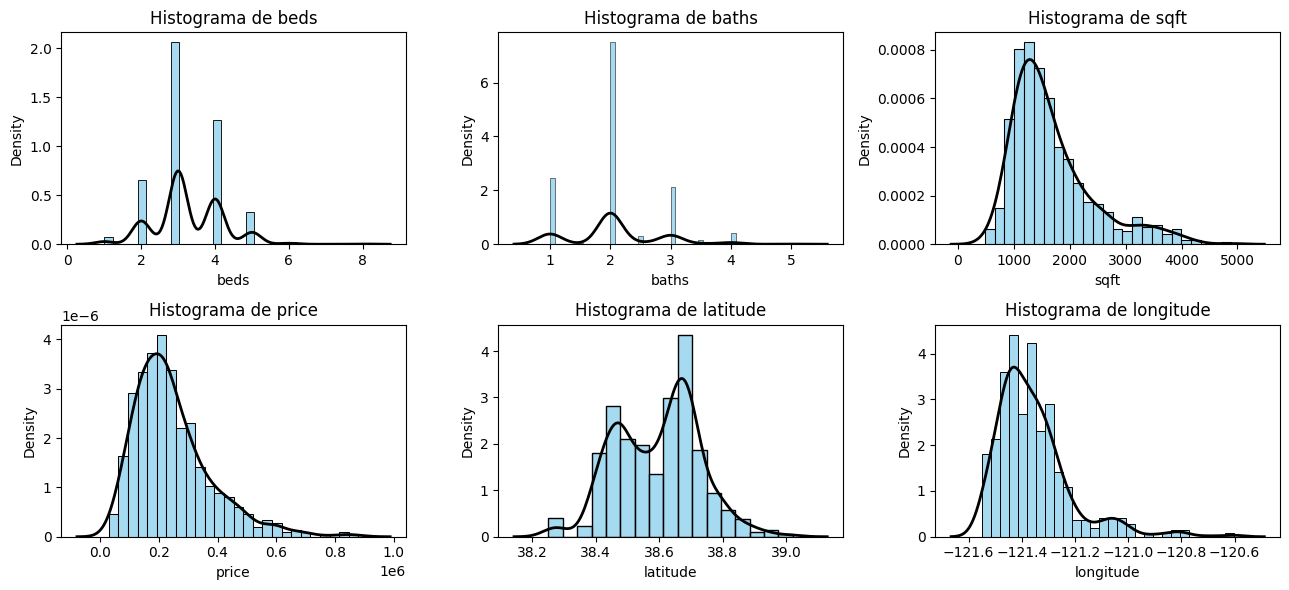

In [34]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (13, 6))
axes = axes.flatten()

for ax, col in zip(axes, numeric_vars):
    # Histograma
    sns.histplot(data_train, x = col, ax = ax, color = 'skyblue', stat = 'density')
    
    # Curva de densidad (KDE)
    sns.kdeplot(data_train[col], ax = ax, color = "black", linewidth = 2)
    
    ax.set_title(f"Histograma de {col}")

plt.tight_layout()
plt.show()

✏️ Observa si existen patrones entre la ubicación de la vivienda, su área y su precio mediante un scatter plot.

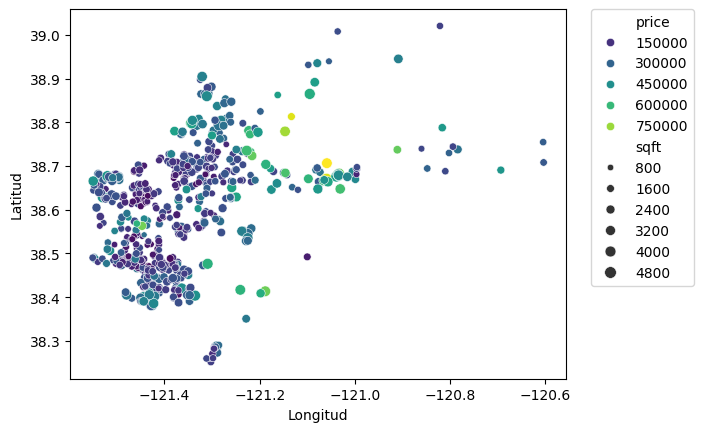

In [35]:
sns.scatterplot(data = data_train, x = 'longitude', y = 'latitude', 
                size = 'sqft', hue = 'price', 
                palette = sns.color_palette("viridis", as_cmap = True))
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left", borderaxespad = 0)
plt.show()

✏️ Construye la matriz de correlación.

In [38]:
cor_mat = data_train.select_dtypes(include=[np.number]).corr()


✏️ Verifica cuáles son las variables más correlacionadas con el precio y detecta problemas potenciales de multicolinealidad.

In [39]:
cor_mat["price"].sort_values(ascending = False)

price        1.000000
sqft         0.760394
baths        0.568644
beds         0.469963
longitude    0.381300
latitude     0.192700
Name: price, dtype: float64

✏️ Grafica la matriz de correlación.

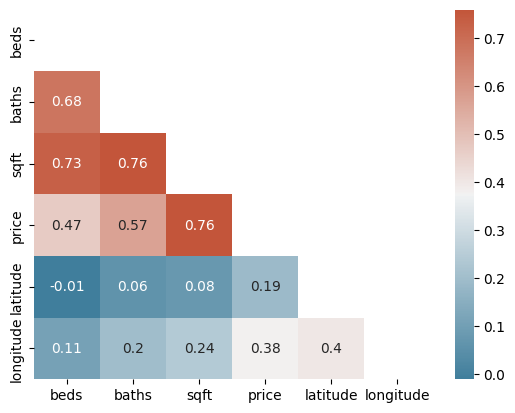

In [40]:
cor_mat = round(cor_mat, 2)
mask = np.triu(np.ones_like(cor_mat, dtype = bool))
col = sns.diverging_palette(230, 20, as_cmap = True)

sns.heatmap(cor_mat, mask = mask, annot = True, cmap = col)
plt.show()

✏️ Construye nuevas variables `baths_per_sqft` y `beds_per_sqft` que representan el cociente entre el número recámaras y baños, y el área de la vivienda, respectivamente.

In [41]:
data_train["baths_per_sqft"] = data_train["baths"] / data_train["sqft"]
data_train["beds_per_sqft"] = data_train["beds"] / data_train["sqft"]

✏️ Verifica si una transformación logarítmica ayuda a que la distribución del área sea más simétrica.

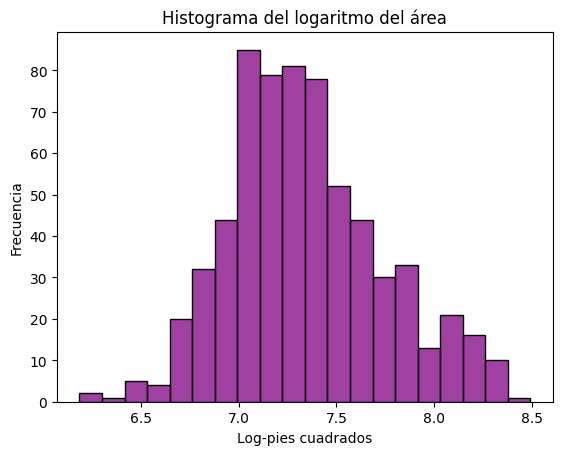

In [42]:
data_train["sqft_log"] = np.log1p(data_train["sqft"]) # Usamos log1p por si hay algún valor en 0
sns.histplot(data = data_train, x = "sqft_log", color = "purple")
plt.xlabel("Log-pies cuadrados")
plt.ylabel("Frecuencia")
plt.title("Histograma del logaritmo del área")
plt.show();

✏️ Utiliza un [isolation forest](https://www.icesi.edu.co/editorial/deteccion-anomalias-web/Isolation.html) para identificar outliers en las variables numéricas.

In [43]:
clf = IsolationForest(random_state = 42)
# Ajustamos el modelo solo con los datos numéricos
clf_fit = clf.fit(data_train[numeric_vars].dropna())

✏️ Usando este método predice cuáles de las observaciones del training set son outliers.

In [44]:
pred = clf_fit.predict(data_train[numeric_vars].dropna())

✏️ Identifica los outliers en el training set.

In [45]:
outliers = data_train.dropna(subset=numeric_vars).loc[pred == -1]
outliers.head()

,city,zip,beds,baths,sqft,type,price,latitude,longitude,baths_per_sqft,beds_per_sqft,sqft_log
467,AUBURN,z95603,2,2.0,1255,Condo,260000.0,38.931671,-121.097862,0.001594,0.001594,7.135687
529,CAMERON_PARK,z95682,4,2.0,2376,Residential,423000.0,38.687072,-121.004729,0.000842,0.001684,7.773594
533,ELK_GROVE,z95757,4,4.0,4303,Residential,450000.0,38.399436,-121.444041,0.000930,0.000930,8.367300
798,FAIR_OAKS,z95628,3,2.0,3173,Residential,525000.0,38.650735,-121.258628,0.000630,0.000945,8.062748
286,LINCOLN,z95648,5,3.0,3072,Residential,315000.0,38.866409,-121.308485,0.000977,0.001628,8.030410


✏️ Verifica que no existan discrepancias en las categorías de la variable `type`.

In [49]:
data_train['type'].unique()

array(['Residential', 'Condo', 'Multi_Family'], dtype=object)

✏️ Verifica que no existan discrepancias en las categorías de la variable `city`.

In [48]:
data_train['city'].unique()

array(['SACRAMENTO', 'CITRUS_HEIGHTS', 'ROSEVILLE', 'AUBURN', 'ELK_GROVE',
       'ROCKLIN', 'EL_DORADO_HILLS', 'CARMICHAEL', 'ANTELOPE',
       'CAMERON_PARK', 'FAIR_OAKS', 'LINCOLN', 'FOLSOM', 'RANCHO_CORDOVA',
       'NORTH_HIGHLANDS', 'WEST_SACRAMENTO', 'GRANITE_BAY',
       'MEADOW_VISTA', 'GALT', 'RIO_LINDA', 'MATHER', 'ELVERTA', 'WILTON',
       'LOOMIS', 'ORANGEVALE', 'GOLD_RIVER', 'PENRYN', 'PLACERVILLE',
       'DIAMOND_SPRINGS', 'RANCHO_MURIETA', 'POLLOCK_PINES', 'GREENWOOD',
       'FORESTHILL'], dtype=object)

✏️ Elimina registros duplicados en el training y test set.

In [50]:
for set_ in (data_train, strat_test):
    set_.drop_duplicates(inplace = True)

✏️ Elimina las variables `city` y `zip` del training y test set.

In [51]:
for set_ in (data_train, strat_test):
    set_.drop(columns = ['city', 'zip'], inplace=True)

✏️ Guarda una copia de los datos de entrenamiento finales en formato `.csv` en la carpeta correspondiente.

In [52]:
data_train.to_csv('../data/processed/Sacramento_Data_Train_Clean.csv', index = False)